In [14]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

factor_df = pd.read_csv("result_factor_rtn.csv")
factor_df = factor_df.rename(columns={'Unnamed: 0': 'Date'})

factor_if = pd.read_csv("factor_master.csv")

with open("list_quantile.pkl", "rb") as f:
    list_quantile = pickle.load(f)

with open("list_sector.pkl", "rb") as f:
    list_sector = pickle.load(f)

with open("list_factor_name.pkl", "rb") as f:
    list_factor_name = pickle.load(f)

with open("list_full_name.pkl", "rb") as f:
    list_full_name = pickle.load(f)

with open("list_returns.pkl", "rb") as f:
    list_returns = pickle.load(f)

with open("list_style_name.pkl", "rb") as f:
    list_style_name = pickle.load(f)

In [ ]:
factor_df_date = factor_df.set_index('Date')
factor_df_date_t = factor_df_date.T.reset_index().rename(columns={'index': 'factor_name'})
factor_df_date_t

Date,factor_name,2009-12-31,2010-01-31,2010-02-28,2010-03-31,2010-04-30,2010-05-31,2010-06-30,2010-07-31,2010-08-31,...,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31
0,EPSEstDispFY2C,0.0,-0.002207,-0.013698,0.001567,0.019733,-0.006266,0.012805,0.014564,-0.000539,...,-0.025678,0.073354,0.046205,0.028071,-0.058007,-0.028241,0.034696,-0.028000,-0.000071,0.011681
1,EstDiffC,0.0,0.006342,0.021717,0.014434,-0.024899,0.016924,0.011247,-0.016430,0.053565,...,0.017509,-0.068324,-0.020081,-0.013935,0.007963,0.013423,0.005214,0.029065,0.004594,-0.010614
2,BuyToSellRecLess3MEMA,0.0,0.005717,0.020947,0.003867,0.024985,0.008447,-0.004124,-0.005267,0.023116,...,0.012279,-0.020361,0.010469,-0.010832,0.012893,-0.011474,-0.018907,-0.002306,0.007298,-0.006848
3,BuyToSellRecLess3MSMA,0.0,0.014420,0.023304,0.004955,0.011512,0.011352,-0.002536,-0.005519,0.029430,...,0.011630,-0.025805,0.015409,-0.011827,0.015599,-0.010994,-0.013685,-0.000948,0.009629,-0.009853
4,EBITEstDisp,0.0,0.003552,0.004336,0.003097,-0.012394,0.007090,0.013013,-0.024939,-0.005243,...,0.018476,-0.038915,-0.047676,-0.021702,0.051024,0.022439,-0.039740,0.041873,-0.013601,-0.004305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,WCAccruals,0.0,-0.024578,-0.006382,-0.010690,0.040548,-0.002722,-0.003312,-0.012882,0.003423,...,0.010085,-0.027896,0.023281,-0.009072,0.007924,-0.001978,0.014479,0.015254,0.011833,0.008068
230,8WChgFwd12MEPS,0.0,-0.012839,0.004302,0.013724,-0.036784,-0.040714,0.014088,0.095214,0.019994,...,-0.008313,-0.009616,0.007330,-0.005337,0.032561,-0.003306,0.008829,0.018853,0.000748,0.005097
231,GPMargin,0.0,0.041148,0.001490,-0.004050,0.021334,0.016996,0.004209,-0.006798,0.025933,...,0.002096,0.026627,-0.047229,0.010491,-0.004929,0.027269,0.018958,0.032787,0.006256,-0.013239
232,InvTurn,0.0,0.012987,0.005005,-0.012225,0.006118,-0.007094,0.003752,-0.018349,-0.021341,...,0.021259,0.005180,-0.021396,-0.011971,0.026981,0.024711,-0.050185,0.006398,0.007530,0.013861


In [3]:
factor_if_abb = factor_if[['factorAbbreviation', 'styleName']]
factor_if_abb = factor_if_abb.rename(columns={'factorAbbreviation': 'factor_name'})
factor_if_abb

,factor_name,styleName
0,ROIC,Capital Efficiency
1,ROE,Capital Efficiency
2,ROA,Capital Efficiency
3,CFROIC,Capital Efficiency
4,DA,Capital Efficiency
...,...,...
582,6MChgTgtPrcGapEMA,Analyst Expectations
583,6MChgTgtPrc,Analyst Expectations
584,6MChgTgtPrcGap,Analyst Expectations
585,RevEstDisp,Analyst Expectations


In [4]:
factor_cum_date = (1 + factor_df_date).cumprod()
factor_cum_date

,EPSEstDispFY2C,EstDiffC,BuyToSellRecLess3MEMA,BuyToSellRecLess3MSMA,EBITEstDisp,EPSSurpC,LTGC,InvPEGC,EPSNumRevFY1C,RevEstDisp,...,FCFEV,FCFP,GFP,InvPEGYC,CFEV,WCAccruals,8WChgFwd12MEPS,GPMargin,InvTurn,AdjChgEPStoSales
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010-01-31,0.997793,1.006342,1.005717,1.014420,1.003552,1.021327,0.989420,0.995850,0.999583,1.033315,...,0.990870,0.990783,1.011634,1.001805,1.010235,0.975422,0.987161,1.041148,1.012987,1.007689
2010-02-28,0.984125,1.028196,1.026784,1.038060,1.007903,1.027106,0.973415,0.985195,1.008327,1.044785,...,0.983790,0.983433,0.989123,0.994789,0.992967,0.969197,0.991408,1.042699,1.018057,1.023306
2010-03-31,0.985667,1.043038,1.030755,1.043203,1.011025,0.990293,0.922362,0.939178,1.016275,1.038606,...,0.979805,0.981285,0.982431,0.950357,0.974475,0.958836,1.005014,1.038476,1.005611,1.039039
2010-04-30,1.005117,1.017067,1.056507,1.055213,0.998494,0.987469,0.944423,0.929248,1.005397,1.024978,...,1.021450,1.019002,0.974911,0.931032,0.949283,0.997715,0.968045,1.060631,1.011763,1.010437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-31,1.123181,3.799798,2.291320,2.007003,0.949203,1.662557,1.448859,1.818321,3.908706,1.259173,...,1.319687,1.397543,1.769381,1.373159,1.148736,1.629627,3.100039,1.129051,0.678755,1.540861
2025-02-28,1.162151,3.819612,2.247998,1.979536,0.911482,1.638007,1.432741,1.757109,3.858839,1.250090,...,1.265595,1.334790,1.727861,1.305708,1.100539,1.653222,3.127408,1.150455,0.644692,1.509666
2025-03-31,1.129611,3.930630,2.242814,1.977659,0.949648,1.663306,1.457469,1.805376,3.912019,1.270422,...,1.301157,1.375669,1.783295,1.334222,1.115071,1.678440,3.186368,1.188175,0.648816,1.531587


In [5]:
# factor_cum_last = factor_cum_date ** (12 / 186)
factor_cum_last = factor_cum_date.iloc[-1:] ** (12 / 186) - 1
factor_cum_last_t = factor_cum_last.T
factor_cum_last_t = factor_cum_last_t.reset_index()
factor_cum_last_t.columns = ['factor_name', 'cagr']
factor_cum_last_t.index.name = None
factor_cum_last_t

,factor_name,cagr
0,EPSEstDispFY2C,0.008645
1,EstDiffC,0.091897
2,BuyToSellRecLess3MEMA,0.053521
3,BuyToSellRecLess3MSMA,0.044955
4,EBITEstDisp,-0.004485
...,...,...
229,WCAccruals,0.035297
230,8WChgFwd12MEPS,0.078038
231,GPMargin,0.010723
232,InvTurn,-0.026189


In [7]:
factor_style_df = pd.merge(factor_cum_last_t, factor_if_abb, on='factor_name', how='inner')
factor_style_df

,factor_name,cagr,styleName
0,EPSEstDispFY2C,0.008645,Analyst Expectations
1,EstDiffC,0.091897,Analyst Expectations
2,BuyToSellRecLess3MEMA,0.053521,Analyst Expectations
3,BuyToSellRecLess3MSMA,0.044955,Analyst Expectations
4,EBITEstDisp,-0.004485,Analyst Expectations
...,...,...,...
229,WCAccruals,0.035297,Earnings Quality
230,8WChgFwd12MEPS,0.078038,Valuation
231,GPMargin,0.010723,Earnings Quality
232,InvTurn,-0.026189,Earnings Quality


In [28]:
factor_style_df = factor_style_df.sort_values('cagr', ascending=False).reset_index(drop=True)
# factor_style_df['rank'] = factor_style_df.groupby('styleName')['cagr'].rank(ascending=False)
factor_style_df['rank'] = factor_style_df['cagr'].rank(ascending=False)
factor_style_df

,factor_name,cagr,styleName,rank
0,RevMagFY1C,0.107499,Analyst Expectations,1.0
1,Rev3MFY1C,0.104840,Analyst Expectations,2.0
2,AdjEPSNumRevFY1C,0.095646,Analyst Expectations,3.0
3,AdjRevMagC,0.094426,Analyst Expectations,4.0
4,PM1M,0.092463,Price Momentum,5.0
...,...,...,...,...
229,4To52WPrcOsc,-0.043722,Price Momentum,230.0
230,CVVolPrc60D,-0.045903,Price Momentum,231.0
231,PM9M,-0.049361,Price Momentum,232.0
232,RSI26W,-0.068255,Price Momentum,233.0


In [106]:
factors = [
    'EstDiffC','BuyToSellRecLess3MEMA','EPSNumRevFY1C','SUEC','RevMagFY1C',
    '6MChgTgtPrcGapEMA','OCFRatio','OCFEqt','6MAvgChg1MRecC','AdjEPSNumRevFY1C',
    'AdjRevMagC','Rev3MFY1C','Rev3MFY2C','CapAcqRatio','CFROIC','AstAdjChg1YFCF',
    'AstAdjChg1YOCF','Alpha60M','PM12M1M','PM1M','24MResRtnVar','PM5D',
    'SalesAcc','AccrualRatioBS','AccrualRatioCF','AdjAccruals','AssetTurn',
    'Chg1YAstTo','PAdjChg1YSales','IO_ChgofNumHD','OCFEV','OCFP','STO',
    '4WChgFwd12MEPS','ChgDeprCapex','DepToCapex','Chg3YOCF','PAdjChg3YOCF',
    'MaxRetPayoff','IO_BreadthStabBY','IO_BreadthStabHD','RskAdjRS','FCFSales',
    'Chg1YFCF','Chg1YOCF','ROEStddev20Q','UnexpectedRecChg','CurLiaP',
    'DivToCF','FCFEqt'
]

In [107]:
# factor_trunc = factor_style_df[(factor_style_df['rank'] <= 50) & (factor_style_df['styleName'] != 'Size')].reset_index(drop=True)
factor_trunc = (
    factor_style_df
    [factor_style_df['factor_name'].isin(factors)]
    .reset_index(drop=True)
)
factor_trunc['styleName'].value_counts()

styleName
Analyst Expectations    11
Price Momentum          11
Historical Growth        9
Earnings Quality         9
Valuation                6
Capital Efficiency       4
Name: count, dtype: int64

In [108]:
selected_factor = factor_trunc[['factor_name', 'styleName']]
selected_factor

,factor_name,styleName
0,RevMagFY1C,Analyst Expectations
1,Rev3MFY1C,Analyst Expectations
2,AdjEPSNumRevFY1C,Analyst Expectations
3,AdjRevMagC,Analyst Expectations
4,PM1M,Price Momentum
5,EstDiffC,Analyst Expectations
6,EPSNumRevFY1C,Analyst Expectations
7,Rev3MFY2C,Analyst Expectations
8,4WChgFwd12MEPS,Valuation
9,Alpha60M,Price Momentum


In [85]:
factor_style_df['styleName'].value_counts()

styleName
Price Momentum          54
Earnings Quality        49
Historical Growth       42
Valuation               35
Capital Efficiency      28
Analyst Expectations    22
Size                     4
Name: count, dtype: int64

In [109]:
test_df = factor_df.set_index('Date')
# test_df = test_df[selected_factor['factor_name'].tolist()]
test_df = test_df[['EstDiffC', 'BuyToSellRecLess3MEMA', 'EPSNumRevFY1C', 'SUEC', 'RevMagFY1C', '6MChgTgtPrcGapEMA', 'OCFRatio', 'OCFEqt', '6MAvgChg1MRecC', 'AdjEPSNumRevFY1C',
                   'AdjRevMagC', 'Rev3MFY1C', 'Rev3MFY2C', 'CapAcqRatio', 'CFROIC', 'AstAdjChg1YFCF', 'AstAdjChg1YOCF', 'Alpha60M', 'PM12M1M', 'PM1M', '24MResRtnVar', 'PM5D', 
                   'SalesAcc', 'AccrualRatioBS', 'AccrualRatioCF', 'AdjAccruals', 'AssetTurn', 'Chg1YAstTo', 'PAdjChg1YSales', 'IO_ChgofNumHD', 'OCFEV', 'OCFP', 'STO', '4WChgFwd12MEPS',
                   'ChgDeprCapex', 'DepToCapex','Chg3YOCF', 'PAdjChg3YOCF', 'MaxRetPayoff', 'IO_BreadthStabBY', 'IO_BreadthStabHD', 'RskAdjRS', 'FCFSales', 'Chg1YFCF', 'Chg1YOCF', 'ROEStddev20Q', 'UnexpectedRecChg', 'CurLiaP', 'DivToCF', 'FCFEqt']]
# test_df = test_df[['EstDiffC', 'EPSSurpC', '6MChgTgtPrcGapEMA', 'OCFRatio', 'TobinQ', 'AdjEPSNumRevFY1C', 'LTDA', 'Rev3MFY1C', 'Rev3MFY2C', '14DayRSI', 'PM1M', '24MResRtnVar', 'AdjSTO_6M', 'CashBurn', '60MAVGTTMEP', 'OEP', 'VolAdjRtn12M', '4WChgFwd12MEPS',
#                    'IO_Concentration', 'IO_BreadthStabBY', 'IO_BreadthStabHD', 'FCFSales', 'Chg1YOCF', 'BP', 'CashEV', 'EP', 'GFP']]

In [110]:
# ------------------------------------------------------------------
# 1) Covariance → Eigen‑decomposition
# ------------------------------------------------------------------
cov_mat = test_df.iloc[1:, :].cov()
eigvals, eigvecs = np.linalg.eigh(cov_mat)          # ascending order
order = eigvals.argsort()[::-1]                      # descending
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

explained_ratio = eigvals / eigvals.sum()
cum_ratio = explained_ratio.cumsum()


Components needed to capture ≥60 % variance: 3

Top 20 eigenvalues
     eigenvalue  explained_ratio  cumulative_ratio
0       0.0087           0.2752            0.2752
1       0.0062           0.1951            0.4703
2       0.0040           0.1278            0.5981
3       0.0018           0.0578            0.6559
4       0.0017           0.0537            0.7096
5       0.0012           0.0369            0.7465
6       0.0008           0.0239            0.7704
7       0.0007           0.0224            0.7928
8       0.0006           0.0194            0.8122
9       0.0005           0.0156            0.8278
10      0.0004           0.0138            0.8416
11      0.0004           0.0127            0.8543
12      0.0004           0.0123            0.8665
13      0.0004           0.0113            0.8778
14      0.0003           0.0100            0.8879
15      0.0003           0.0093            0.8972
16      0.0003           0.0087            0.9059
17      0.0003           0.0081

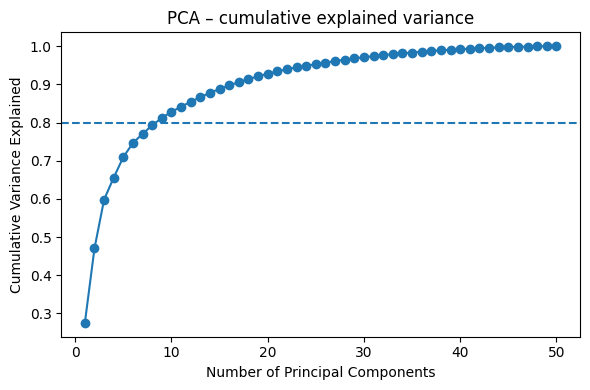

In [111]:
import os
# ------------------------------------------------------------------
# 2)  Components needed to reach 60 % variance
# ------------------------------------------------------------------
k = np.argmax(cum_ratio >= 0.50) + 1
print(f"\nComponents needed to capture ≥60 % variance: {k}\n")

# ------------------------------------------------------------------
# 3)  Tables
# ------------------------------------------------------------------
eig_table = pd.DataFrame({
    "eigenvalue": eigvals,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cum_ratio,
})

print("Top 20 eigenvalues\n", eig_table.head(20).round(4), "\n")

pc_loadings = pd.DataFrame(
    eigvecs[:, :k],
    index=test_df.columns,
    columns=[f"PC{i+1}" for i in range(k)],
)
print(f"First {k} principal component loadings (first 10 rows)\n",
      pc_loadings.head(10).round(4), "\n")

# ------------------------------------------------------------------
# 4)  Save to CSV so the user can download
# ------------------------------------------------------------------
out_dir = "./mnt/data"
eig_csv = os.path.join(out_dir, "eigenvalues.csv")
load_csv = os.path.join(out_dir, "pc_loadings.csv")

eig_table.to_csv(eig_csv, index_label="PC")
pc_loadings.to_csv(load_csv, index_label="Factor")

print(f"CSV files saved:\n  • {eig_csv}\n  • {load_csv}\n")

# ------------------------------------------------------------------
# 5)  Plot cumulative explained variance
# ------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cum_ratio) + 1), cum_ratio, marker="o")
plt.axhline(0.80, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA – cumulative explained variance")
plt.tight_layout()
plt.show()

In [112]:
wgt_loadings = (pc_loadings ** 2) /  (pc_loadings ** 2).sum(axis=0).values.reshape(1, -1)

In [113]:
wgt_loadings * 100

,PC1,PC2,PC3
EstDiffC,1.025391,3.392669,0.004056
BuyToSellRecLess3MEMA,0.088496,0.380884,0.123024
EPSNumRevFY1C,1.191015,3.557719,0.053128
SUEC,1.160160,2.527780,0.080610
RevMagFY1C,1.280218,4.315329,0.690344
6MChgTgtPrcGapEMA,0.492969,0.068712,13.806434
OCFRatio,1.358388,0.808394,0.731445
OCFEqt,3.221070,0.391680,1.184867
6MAvgChg1MRecC,0.051239,0.482460,0.424174
AdjEPSNumRevFY1C,0.912934,3.417907,0.025038


In [114]:
pc_ret = test_df @ wgt_loadings
pc_ret

,PC1,PC2,PC3
Date,,,
2009-12-31,0.000000,0.000000,0.000000
2010-01-31,0.008170,-0.007454,-0.005119
2010-02-28,-0.004127,0.008425,-0.000701
2010-03-31,-0.007961,0.003184,0.007131
2010-04-30,0.011053,0.001348,-0.010474
...,...,...,...
2025-01-31,0.008074,0.012156,-0.002553
2025-02-28,-0.013939,-0.014502,0.005308
2025-03-31,0.019043,0.015426,0.033763


In [115]:
pc_ret.corr()

,PC1,PC2,PC3
PC1,1.000000,0.603882,0.110603
PC2,0.603882,1.000000,-0.012092
PC3,0.110603,-0.012092,1.000000


In [116]:
pc_loadings

,PC1,PC2,PC3
EstDiffC,-0.101262,-0.184192,0.006368
BuyToSellRecLess3MEMA,-0.029748,-0.061716,0.035075
EPSNumRevFY1C,-0.109134,-0.188619,0.023050
SUEC,-0.107711,-0.158990,0.028392
RevMagFY1C,-0.113147,-0.207734,0.083087
6MChgTgtPrcGapEMA,0.070212,0.026213,0.371570
OCFRatio,-0.116550,-0.089911,0.085525
OCFEqt,-0.179473,-0.062584,0.108852
6MAvgChg1MRecC,-0.022636,-0.069459,0.065129
AdjEPSNumRevFY1C,-0.095548,-0.184876,0.015823


In [117]:
pc_loadings_reset = pc_loadings.reset_index().rename(columns={'index': 'factor_name'})
pc_loadings_reset

,factor_name,PC1,PC2,PC3
0,EstDiffC,-0.101262,-0.184192,0.006368
1,BuyToSellRecLess3MEMA,-0.029748,-0.061716,0.035075
2,EPSNumRevFY1C,-0.109134,-0.188619,0.023050
3,SUEC,-0.107711,-0.158990,0.028392
4,RevMagFY1C,-0.113147,-0.207734,0.083087
5,6MChgTgtPrcGapEMA,0.070212,0.026213,0.371570
6,OCFRatio,-0.116550,-0.089911,0.085525
7,OCFEqt,-0.179473,-0.062584,0.108852
8,6MAvgChg1MRecC,-0.022636,-0.069459,0.065129
9,AdjEPSNumRevFY1C,-0.095548,-0.184876,0.015823


In [118]:
pc_loadings_reset = pd.merge(selected_factor, pc_loadings_reset, on='factor_name', how='inner')
pc_loadings_reset

,factor_name,styleName,PC1,PC2,PC3
0,RevMagFY1C,Analyst Expectations,-0.113147,-0.207734,0.083087
1,Rev3MFY1C,Analyst Expectations,-0.104308,-0.205707,0.064651
2,AdjEPSNumRevFY1C,Analyst Expectations,-0.095548,-0.184876,0.015823
3,AdjRevMagC,Analyst Expectations,-0.122763,-0.204141,0.072852
4,PM1M,Price Momentum,0.211616,0.152684,0.430942
5,EstDiffC,Analyst Expectations,-0.101262,-0.184192,0.006368
6,EPSNumRevFY1C,Analyst Expectations,-0.109134,-0.188619,0.023050
7,Rev3MFY2C,Analyst Expectations,-0.088400,-0.234237,0.115430
8,4WChgFwd12MEPS,Valuation,0.125506,0.043266,0.367664
9,Alpha60M,Price Momentum,0.189498,0.131199,0.389473


In [123]:
import plotly.graph_objs as go
import plotly.express as px

from plotly.offline import plot


vars_ = pc_loadings_reset['factor_name'].tolist()
styles = pc_loadings_reset['styleName'].tolist()

loadings = pc_loadings_reset.copy()
loadings = loadings.set_index('factor_name')
# -----------------------------------------------------------
loadings['Style'] = styles

def plot_loadings_3d(loadings_df, size=8):
    unique_styles = loadings_df['Style'].unique()
    colors = px.colors.qualitative.Plotly
    color_map = {s: colors[i % len(colors)] for i, s in enumerate(unique_styles)}
    
    x, y, z   = loadings_df['PC1'], loadings_df['PC2'], loadings_df['PC3']
    labels    = loadings_df.index.astype(str)
    style_col = loadings_df['Style']

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers+text',
        marker=dict(size=size,
                    color=[color_map[s] for s in style_col],
                    opacity=0.85),
        text=labels,
        textposition="top center",
        hovertemplate=(
            "<b>%{text}</b><br>PC1=%{x:.2f}<br>PC2=%{y:.2f}<br>"
            "PC3=%{z:.2f}<br>Style=%{customdata}"),
        customdata=style_col
    )

    layout = go.Layout(
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3',
            aspectmode='cube'
        ),
        legend=dict(itemsizing='constant'),
        margin=dict(l=0, r=0, b=0, t=50),
        title='3-D PCA Loadings by Style'
    )
    fig = go.Figure(data=[trace], layout=layout)
    plot(fig)
    
plot_loadings_3d(loadings)


In [168]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go

# 기존 변수‧로딩·스타일 DataFrame ------------------------------------------------
# loadings_df: index=변수명, 컬럼 ['PC1','PC2','PC3','Style'] (앞서 만들었던 것)

# 1) 3-D 산점도 ----------------------------------------------------------------
def base_scatter(loadings_df, size=8):
    # 색 매핑 (Style별)
    styles = loadings_df['Style'].unique()
    palette = px.colors.qualitative.Plotly
    color_map = {s: palette[i % len(palette)] for i, s in enumerate(styles)}

    sc = go.Scatter3d(
        x=loadings_df['PC1'],
        y=loadings_df['PC2'],
        z=loadings_df['PC3'],
        mode='markers+text',
        marker=dict(size=size,
                    color=[color_map[s] for s in loadings_df['Style']],
                    opacity=0.85),
        text=loadings_df.index,
        textposition='top center',
        customdata=loadings_df['Style'],
        hovertemplate=(
            "<b>%{text}</b><br>PC1=%{x:.2f}<br>PC2=%{y:.2f}"
            "<br>PC3=%{z:.2f}<br>Style=%{customdata}")
    )
    fig = go.Figure(data=[sc])
    fig.update_layout(
        scene=dict(aspectmode='cube',
                   xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
        title='3-D PCA Loadings + Eigenvectors'
    )
    return fig

def add_pc_axes(fig, loadings_df, factor=1.2, width=1, head=0.04,
                colors=('red', 'green', 'blue')):
    """
    factor   : 산점도 최대 절댓값 대비 축 길이 배수
    width    : 축 선 굵기 (픽셀)
    head     : 화살촉 크기 (sizeref)
    colors   : PC1, PC2, PC3 색을 나타내는 3-tuple
    """
    # ── 길이 스케일 ───────────────────────────────────────────
    max_coord = np.abs(loadings_df[['PC1','PC2','PC3']]).values.max()
    scale = max_coord * factor

    # ── 단위벡터 ─────────────────────────────────────────────
    vecs = loadings_df[['PC1','PC2','PC3']].to_numpy().T
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)

    for k, v in enumerate(vecs):
        col = colors[k % len(colors)]
        # 선
        fig.add_trace(go.Scatter3d(
            x=[0, v[0]*scale], y=[0, v[1]*scale], z=[0, v[2]*scale],
            mode='lines',
            line=dict(width=width, color=col),
            hoverinfo='skip', showlegend=False
        ))
        # 화살촉
        fig.add_trace(go.Cone(
            x=[v[0]*scale], y=[v[1]*scale], z=[v[2]*scale],
            u=[v[0]], v=[v[1]], w=[v[2]],
            sizemode='absolute', sizeref=head,
            anchor='tip', showscale=False,
            colorscale=[[0, col], [1, col]],
            hoverinfo='skip', showlegend=False
        ))
    return fig

fig = base_scatter(loadings)
fig = add_pc_axes(fig,
                  loadings,
                  factor=1.1,          # 축 길이
                  width=1,             # 선 굵기
                  head=0.03,           # 화살촉
                  colors=('red','green','blue'))  # 축별 색
plot(fig)

'temp-plot.html'

In [120]:
loadings

,PC1,PC2,PC3,Style
EstDiffC,-0.101262,-0.184192,0.006368,Analyst Expectations
BuyToSellRecLess3MEMA,-0.029748,-0.061716,0.035075,Analyst Expectations
EPSNumRevFY1C,-0.109134,-0.188619,0.023050,Analyst Expectations
SUEC,-0.107711,-0.158990,0.028392,Analyst Expectations
RevMagFY1C,-0.113147,-0.207734,0.083087,Price Momentum
6MChgTgtPrcGapEMA,0.070212,0.026213,0.371570,Analyst Expectations
OCFRatio,-0.116550,-0.089911,0.085525,Analyst Expectations
OCFEqt,-0.179473,-0.062584,0.108852,Analyst Expectations
6MAvgChg1MRecC,-0.022636,-0.069459,0.065129,Valuation
AdjEPSNumRevFY1C,-0.095548,-0.184876,0.015823,Price Momentum


In [72]:
# (1 + pc_ret.iloc[:, 2]).cumprod().plot()

<Axes: xlabel='Date'>

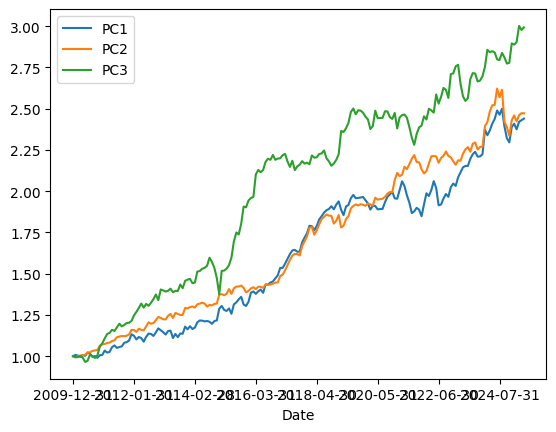

In [124]:
(1 + pc_ret).cumprod().plot()

<Axes: xlabel='Date'>

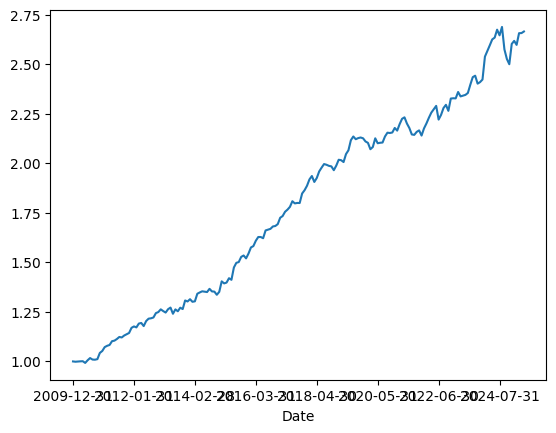

In [125]:
(1 + pc_ret.mean(axis=1)).cumprod().plot()

In [133]:
pc_ewm = pc_ret.ewm(span=36).mean()
pc_std = pc_ret.ewm(span=36).std()

In [142]:
pc_srp = pc_ewm / pc_std * np.sqrt(12)
pc_srp = pc_srp[36:]
import scipy.stats as stats

pc_wgt = stats.norm.cdf(pc_srp, scale=0.5)
pc_wgt

array([[0.98129826, 0.99998489, 0.99994607],
       [0.95414639, 0.99983412, 0.99983121],
       [0.89299346, 0.99966843, 0.99952558],
       [0.9533807 , 0.99994808, 0.99947118],
       [0.95347526, 0.99998102, 0.99964752],
       [0.66416684, 0.99616216, 0.99712864],
       [0.81944057, 0.99933166, 0.99757346],
       [0.67911928, 0.99794036, 0.99666788],
       [0.81155933, 0.99497372, 0.99924686],
       [0.7954472 , 0.99387435, 0.99487293],
       [0.93573728, 0.99899271, 0.9988745 ],
       [0.87414558, 0.99800579, 0.9989475 ],
       [0.92534544, 0.99871568, 0.99888393],
       [0.85429716, 0.99863616, 0.99155317],
       [0.88242957, 0.99661792, 0.99114945],
       [0.9533617 , 0.99893069, 0.99842936],
       [0.96597782, 0.99898668, 0.99821327],
       [0.96029576, 0.99916792, 0.99876158],
       [0.94608776, 0.9977978 , 0.99870068],
       [0.94569205, 0.98282227, 0.99906824],
       [0.92822366, 0.98977697, 0.99982006],
       [0.8738094 , 0.98452092, 0.99832657],
       [0.

In [143]:
pc_wgt = pd.DataFrame(data=pc_wgt, columns=['PC1', 'PC2', 'PC3'], index=pc_srp.index)
pc_wgt = pc_wgt / pc_wgt.sum(axis=1).values.reshape(-1, 1)

<Axes: xlabel='Date'>

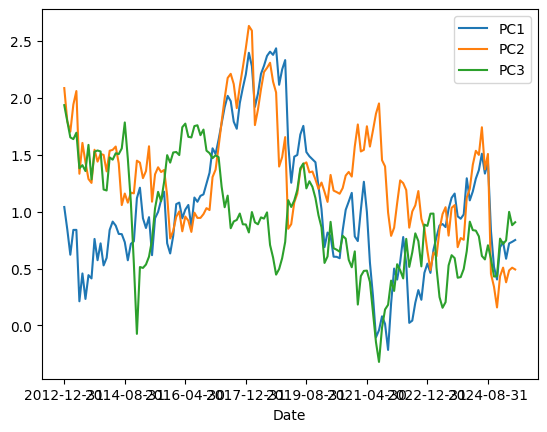

In [137]:
pc_srp.plot()

<Axes: xlabel='Date'>

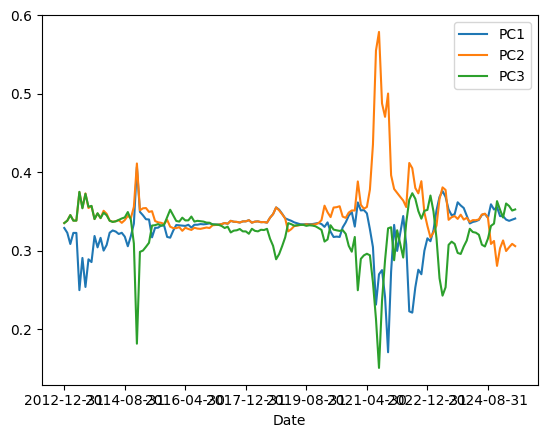

In [144]:
pc_wgt.plot()

In [145]:
pc_wgt

,PC1,PC2,PC3
Date,,,
2012-12-31,0.329159,0.335427,0.335414
2013-01-31,0.323022,0.338489,0.338488
2013-02-28,0.308761,0.345644,0.345595
2013-03-31,0.322873,0.338644,0.338483
2013-04-30,0.322872,0.338620,0.338507
...,...,...,...
2025-01-31,0.344220,0.313295,0.342485
2025-02-28,0.339834,0.299797,0.360369
2025-03-31,0.338266,0.304571,0.357163


In [146]:
pc_ret

,PC1,PC2,PC3
Date,,,
2009-12-31,0.000000,0.000000,0.000000
2010-01-31,0.008170,-0.007454,-0.005119
2010-02-28,-0.004127,0.008425,-0.000701
2010-03-31,-0.007961,0.003184,0.007131
2010-04-30,0.011053,0.001348,-0.010474
...,...,...,...
2025-01-31,0.008074,0.012156,-0.002553
2025-02-28,-0.013939,-0.014502,0.005308
2025-03-31,0.019043,0.015426,0.033763


In [160]:
pc_tot = pc_wgt.shift(1) * pc_ret[36:]
pc_tot = pc_tot.fillna(0)
pc_tot['port'] = pc_tot.sum(axis=1)
pc_tot

,PC1,PC2,PC3,port
Date,,,,
2012-12-31,0.000000,0.000000,0.000000,0.000000
2013-01-31,-0.003288,-0.002162,-0.001443,-0.006893
2013-02-28,-0.004000,-0.000284,-0.001597,-0.005880
2013-03-31,0.005850,0.006359,0.001187,0.013396
2013-04-30,0.000613,0.002959,0.003044,0.006617
...,...,...,...,...
2025-01-31,0.002780,0.003687,-0.000900,0.005567
2025-02-28,-0.004798,-0.004543,0.001818,-0.007524
2025-03-31,0.006472,0.004625,0.012167,0.023264


<Axes: xlabel='Date'>

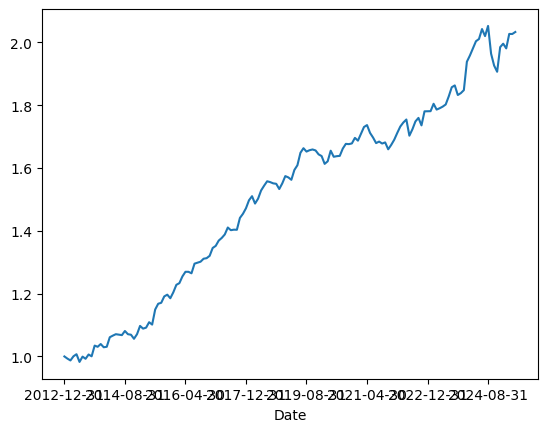

In [161]:
(1 + pc_tot['port']).cumprod().plot()

In [ ]:
# def plot_factor_returns(data, factor_name, mode):

#     if mode == 'Factor Return':
#         df = data.copy()
#         df['cum'] = (1 + df[f'{factor_name}']).cumprod()
#         plt.figure(figsize=(12, 6))
#         plt.title(f'{factor_name} Cumulative Return Performance')
#         plt.plot(df.index, (df['cum'] - 1) * 100, color='black')
#         plt.show()
    
#     elif mode == 'Sector Return Histogram':
#         quantiles = data.index.tolist()          # ['Q1', 'Q2', ..., 'Q5']
#         sectors = data.columns.tolist()          # ['Tech', 'Energy', ...]

#         bar_width = 0.15
#         x = np.arange(len(sectors))
#         colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

#         fig, ax = plt.subplots(figsize=(12, 6))


#         for i, quantile in enumerate(quantiles):
#             values = data.loc[quantile].values
#             offset = (i - 2) * bar_width
#             ax.bar(
#                 x + offset,
#                 values,
#                 width=bar_width,
#                 label=quantile,
#                 color=colors[i],
#                 edgecolor='black'
#             )

#         ax.set_xticks(x)
#         ax.set_xticklabels(sectors, rotation=45, ha='right')
#         ax.set_ylabel('Return (%)')
#         ax.set_title(f'{factor_name} Sector Quantile Grouped Bar Chart')
#         ax.legend(title='Quantile')
#         plt.tight_layout()
#         plt.show()

#     else:
#         # Annualized Return by Quantile - Bar
#         df_result_mean = data.mean(axis=0).to_frame()
#         df_result_mean = df_result_mean.rename(columns={0: 'Avg Return(%)'})
#         df_result_mean = df_result_mean.sort_index(ascending=True)

#         plt.figure(figsize=(12, 6))
#         plt.bar(df_result_mean.index, df_result_mean['Avg Return(%)'] * 100 * 12, color='blue')
#         plt.xlabel('Quantile')
#         plt.ylabel('AvgReturn(%)')
#         plt.title(f'{factor_name} Annualized Average Return % by Quantile')
#         plt.plot()
#         plt.show()

    
# def plot_factor_returns(data, factor_name, mode):

#     if mode == 'Factor Return':
#         data['cum'] = (1 + data[f'{factor_name}']).cumprod()
#         plt.figure(figsize=(12, 6))
#         plt.title(f'{factor_name} Cumulative Return Performance')
#         plt.plot(data.index, (data['cum'] - 1) * 100, color='black')
#         plt.show()
    
#     elif mode == 'Sector Return Histogram':
#         quantiles = data.index.tolist()          # ['Q1', 'Q2', ..., 'Q5']
#         sectors = data.columns.tolist()          # ['Tech', 'Energy', ...]

#         bar_width = 0.15
#         x = np.arange(len(sectors))
#         colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

#         fig, ax = plt.subplots(figsize=(12, 6))


#         for i, quantile in enumerate(quantiles):
#             values = data.loc[quantile].values
#             offset = (i - 2) * bar_width
#             ax.bar(
#                 x + offset,
#                 values,
#                 width=bar_width,
#                 label=quantile,
#                 color=colors[i],
#                 edgecolor='black'
#             )

#         ax.set_xticks(x)
#         ax.set_xticklabels(sectors, rotation=45, ha='right')
#         ax.set_ylabel('Return (%)')
#         ax.set_title(f'{factor_name} Sector Quantile Grouped Bar Chart')
#         ax.legend(title='Quantile')
#         plt.tight_layout()
#         plt.show()

#     else:
#         # Annualized Return by Quantile - Bar
#         df_result_mean = data.mean(axis=0).to_frame()
#         df_result_mean = df_result_mean.rename(columns={0: 'Avg Return(%)'})
#         df_result_mean = df_result_mean.sort_index(ascending=True)

#         plt.figure(figsize=(12, 6))
#         plt.bar(df_result_mean.index, df_result_mean['Avg Return(%)'] * 100 * 12, color='blue')
#         plt.xlabel('Quantile')
#         plt.ylabel('AvgReturn(%)')
#         plt.title('Annualized Average Return % by Quantile')
#         plt.plot()
#         plt.show()

In [39]:
STYLE_COLORS = {
    "Valuation":            "#d62728",   # Red
    "Price Momentum":       "#ff7f0e",   # Orange
    "Earnings Quality":     "#e377c2",   # Bright Pink
    "Size":                 "#2ca02c",   # Green
    "Analyst Expectations": "#17becf",   # Cyan / Teal
    "Historical Growth":    "#8c564b",   # Brown
    "Capital Efficiency":   "#bcbd22"    # Olive (high-contrast yellow-green)
}



def plot_factor_returns(data, style_name, factor_name, name, mode, ax=None, show=False):

    colour = STYLE_COLORS.get(style_name, "black")

    if data is None:
        pass
    else:
        created_new = ax is None
        if created_new:
            fig, ax = plt.subplots(figsize=(12, 6))
        else:
            fig = ax.figure

        if mode == 'Factor Return':
            df = data.copy()
            df['cum'] = (1 + df[factor_name]).cumprod()
            ax.set_title(f'{name}', fontsize=8, color=colour)
            ax.plot(df.index, (df['cum'] - 1) * 100, color=colour)

        elif mode == 'Sector Return Histogram':

            data = data.rename(columns={'Communication Services': 'CS', 'Consumer Discretionary': 'Cons. Disc.', 'Consumer Staples': 'Cons. Stap.', 'Information Technology': 'IT'})
            quantiles = data.index.tolist()
            sectors = data.columns.tolist()
            bar_width = 0.15
            x = np.arange(len(sectors))
            colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

            for i, q in enumerate(quantiles):
                vals = data.loc[q].values
                offset = (i - 2) * bar_width
                ax.bar(x + offset, vals, width=bar_width,
                    label=q, color=colors[i], edgecolor='black')

            ax.set_xticks(x)
            ax.set_xticklabels(sectors, rotation=45, ha='right')
            ax.set_ylabel('Return (%)')
            ax.set_title(f'{name}', fontsize=8, color=colour)

        else:                                  # Annualized by Quantile
            df_mean = data.mean(axis=0).sort_index().to_frame('Avg') * 100 * 12
            ax.bar(df_mean.index, df_mean['Avg'], color=colour)
            ax.set_xlabel('Quantile')
            ax.set_ylabel('AvgReturn(%)')
            ax.set_title(f'{name}', fontsize=8, color=colour)

        if created_new:
            plt.tight_layout()
        return fig

In [40]:
# plot_factor_returns(list_sector[1].iloc[1:, :], list_factor_name[1], 'Sector Return Histogram')

In [41]:
# plot_factor_returns(list_returns[21], list_factor_name[21], 'Factor Return')

In [42]:
# plot_factor_returns(list_quantile[0].iloc[:, 1:], list_factor_name[0], 'Quantile Spread')

In [43]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

plt.ioff()  # 노트북 화면 자동 출력 끄기

rows, cols  = 3, 4
per_page    = rows * cols
file_name   = "factor_returns_pages_sorted_by_cagr.pdf"

with PdfPages(file_name) as pp:

    # 앞서 정의한 rows, cols 사용
    fig_legend, ax_legend = plt.subplots(
        figsize=(cols * 4, rows * 3)  # (16, 9) – 본문과 같은 크기
    )
    ax_legend.set_axis_off()

    # 가로 두 칼럼(4×2)으로 배치
    for i, (style, hexcol) in enumerate(STYLE_COLORS.items()):
        row = i // 2
        col = i % 2
        y   = 0.95 - 0.14 * row          # 세로 위치 (약간 여백)
        x   = 0.07 + 0.46 * col       # 좌우 위치

        # 컬러 사각형
        ax_legend.add_patch(
            Rectangle((x, y-0.04), 0.09, 0.09,
                      facecolor=hexcol, edgecolor="black")
        )
        # 텍스트
        ax_legend.text(x + 0.12, y, style,
                       fontsize=13, va="center")

    # 제목: pad 를 크게, 색 안 잘리게 top 여백 확보
    ax_legend.set_title("Factor-Style Colour Key",
                        fontsize=18, pad=30)

    # 위·아래·좌·우 margin 확보 (잘림 방지)
    fig_legend.subplots_adjust(top=0.90, bottom=0.05,
                            left=0.05, right=0.95)

    pp.savefig(fig_legend)
    plt.close(fig_legend)

    ##

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    idx_in_page = 0
    total = len(list_returns)

    for i, (ret, style_name, factor_name, full_name) in enumerate(zip(list_returns, list_style_name, list_factor_name, list_full_name), 1):
        ax = axes.flat[idx_in_page]     # 현재 칸

        try:
            res = plot_factor_returns(ret, style_name, factor_name, full_name,
                                      "Factor Return", ax=ax, show=False)
            if res is None:
                logging.warning(f"[{i}/{total}] {factor_name} → None, skip")
                continue                # **axis("off") 호출 안 함**
        except Exception as e:
            logging.error(f"[{i}/{total}] {factor_name} fail: {e}")
            continue                    # 역시 axis 상태 건드리지 않음

        # 성공적으로 그렸다면 (혹시 이전에 꺼졌을 수도 있으니) 축 켜기
        ax.set_axis_on()
        idx_in_page += 1

        # 페이지가 가득 찼거나 마지막 데이터면 저장
        is_last = i == total
        if idx_in_page == per_page or is_last:
            for empty_ax in axes.flat[idx_in_page:]:
                empty_ax.axis("off")    # 최종 빈 칸만 깔끔히 제거
            fig.tight_layout()
            pp.savefig(fig)
            plt.close(fig)

            if not is_last:            # 다음 페이지 준비
                fig, axes = plt.subplots(rows, cols,
                                         figsize=(cols*4, rows*3))
                idx_in_page = 0

plt.close("all")  # 혹시 남은 Figure 전부 정리
print(f"PDF 저장 완료 → {file_name}")


PDF 저장 완료 → factor_returns_pages_sorted_by_cagr.pdf


In [44]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

plt.ioff()  # 노트북 화면 자동 출력 끄기

rows, cols  = 3, 4
per_page    = rows * cols
file_name   = "quantile_returns_pages_sorted_by_cagr.pdf"

with PdfPages(file_name) as pp:

    # 앞서 정의한 rows, cols 사용
    fig_legend, ax_legend = plt.subplots(
        figsize=(cols * 4, rows * 3)  # (16, 9) – 본문과 같은 크기
    )
    ax_legend.set_axis_off()

    # 가로 두 칼럼(4×2)으로 배치
    for i, (style, hexcol) in enumerate(STYLE_COLORS.items()):
        row = i // 2
        col = i % 2
        y   = 0.95 - 0.14 * row          # 세로 위치 (약간 여백)
        x   = 0.07 + 0.46 * col       # 좌우 위치

        # 컬러 사각형
        ax_legend.add_patch(
            Rectangle((x, y-0.04), 0.09, 0.09,
                      facecolor=hexcol, edgecolor="black")
        )
        # 텍스트
        ax_legend.text(x + 0.12, y, style,
                       fontsize=13, va="center")

    # 제목: pad 를 크게, 색 안 잘리게 top 여백 확보
    ax_legend.set_title("Factor-Style Colour Key",
                        fontsize=18, pad=30)

    # 위·아래·좌·우 margin 확보 (잘림 방지)
    fig_legend.subplots_adjust(top=0.90, bottom=0.05,
                            left=0.05, right=0.95)

    pp.savefig(fig_legend)
    plt.close(fig_legend)

    ##
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    idx_in_page = 0
    total = len(list_quantile)

    for i, (q, style_name, factor_name, full_name) in enumerate(zip(list_quantile, list_style_name, list_factor_name, list_full_name), 1):
        ax = axes.flat[idx_in_page]     # 현재 칸

        try:
            res = plot_factor_returns(q.iloc[:, 1:], style_name, factor_name, full_name,
                                      "Quantile Spread", ax=ax, show=False)
            if res is None:
                logging.warning(f"[{i}/{total}] {factor_name} → None, skip")
                continue                # **axis("off") 호출 안 함**
        except Exception as e:
            logging.error(f"[{i}/{total}] {factor_name} fail: {e}")
            continue                    # 역시 axis 상태 건드리지 않음

        # 성공적으로 그렸다면 (혹시 이전에 꺼졌을 수도 있으니) 축 켜기
        ax.set_axis_on()
        idx_in_page += 1

        # 페이지가 가득 찼거나 마지막 데이터면 저장
        is_last = i == total
        if idx_in_page == per_page or is_last:
            for empty_ax in axes.flat[idx_in_page:]:
                empty_ax.axis("off")    # 최종 빈 칸만 깔끔히 제거
            fig.tight_layout()
            pp.savefig(fig)
            plt.close(fig)

            if not is_last:            # 다음 페이지 준비
                fig, axes = plt.subplots(rows, cols,
                                         figsize=(cols*4, rows*3))
                idx_in_page = 0

plt.close("all")  # 혹시 남은 Figure 전부 정리
print(f"PDF 저장 완료 → {file_name}")


PDF 저장 완료 → quantile_returns_pages_sorted_by_cagr.pdf


In [45]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

plt.ioff()  # 노트북 화면 자동 출력 끄기

rows, cols  = 3, 4
per_page    = rows * cols
file_name   = "sector_returns_pages_sorted_by_cagr.pdf"

with PdfPages(file_name) as pp:

    # 앞서 정의한 rows, cols 사용
    fig_legend, ax_legend = plt.subplots(
        figsize=(cols * 4, rows * 3)  # (16, 9) – 본문과 같은 크기
    )
    ax_legend.set_axis_off()

    # 가로 두 칼럼(4×2)으로 배치
    for i, (style, hexcol) in enumerate(STYLE_COLORS.items()):
        row = i // 2
        col = i % 2
        y   = 0.95 - 0.14 * row          # 세로 위치 (약간 여백)
        x   = 0.07 + 0.46 * col       # 좌우 위치

        # 컬러 사각형
        ax_legend.add_patch(
            Rectangle((x, y-0.04), 0.09, 0.09,
                      facecolor=hexcol, edgecolor="black")
        )
        # 텍스트
        ax_legend.text(x + 0.12, y, style,
                       fontsize=13, va="center")

    # 제목: pad 를 크게, 색 안 잘리게 top 여백 확보
    ax_legend.set_title("Factor-Style Colour Key",
                        fontsize=18, pad=30)

    # 위·아래·좌·우 margin 확보 (잘림 방지)
    fig_legend.subplots_adjust(top=0.90, bottom=0.05,
                            left=0.05, right=0.95)

    pp.savefig(fig_legend)
    plt.close(fig_legend)

    ##

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    idx_in_page = 0
    total = len(list_sector)

    for i, (sec, style_name, factor_name, full_name) in enumerate(zip(list_sector, list_style_name, list_factor_name, list_full_name), 1):
        ax = axes.flat[idx_in_page]     # 현재 칸

        try:
            res = plot_factor_returns(sec.iloc[1:, :], style_name, factor_name, full_name,
                                      "Sector Return Histogram", ax=ax, show=False)
            if res is None:
                logging.warning(f"[{i}/{total}] {factor_name} → None, skip")
                continue                # **axis("off") 호출 안 함**
        except Exception as e:
            logging.error(f"[{i}/{total}] {factor_name} fail: {e}")
            continue                    # 역시 axis 상태 건드리지 않음

        # 성공적으로 그렸다면 (혹시 이전에 꺼졌을 수도 있으니) 축 켜기
        ax.set_axis_on()
        idx_in_page += 1

        # 페이지가 가득 찼거나 마지막 데이터면 저장
        is_last = i == total
        if idx_in_page == per_page or is_last:
            for empty_ax in axes.flat[idx_in_page:]:
                empty_ax.axis("off")    # 최종 빈 칸만 깔끔히 제거
            fig.tight_layout()
            pp.savefig(fig)
            plt.close(fig)

            if not is_last:            # 다음 페이지 준비
                fig, axes = plt.subplots(rows, cols,
                                         figsize=(cols*4, rows*3))
                idx_in_page = 0

plt.close("all")  # 혹시 남은 Figure 전부 정리
print(f"PDF 저장 완료 → {file_name}")


PDF 저장 완료 → sector_returns_pages_sorted_by_cagr.pdf


In [136]:
factor_df = factor_df.rename(columns={'Unnamed: 0': 'Date'})
factor_df

,Date,ROE,ROIC,TobinQ,WCTurn,DebtChg1Y,Rev3MFY1C,Rev3MFY2C,6MAvgChg1MRecC,6MChgTgtPrc,...,STO_6M,PM6M,CVVolPrc60D,Alpha60M,Alpha12M6MPChg,Alpha18M6MPChg,Alpha36M6MPChg,PM9M,AdjSTO_6M,EPSStab
0,2009-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2010-01-31,0.040976,0.015814,0.039644,0.039779,-0.035505,0.018409,0.070779,-0.025679,0.078163,...,0.190349,0.051371,-0.003104,0.014241,0.053829,-0.031887,0.050391,0.055912,0.082027,-0.038356
2,2010-02-28,0.000733,-0.003495,-0.014682,0.000552,-0.003565,-0.009669,-0.011547,-0.013164,0.017297,...,-0.041278,-0.006718,-0.024376,-0.001736,-0.029082,-0.024219,-0.009397,-0.016564,-0.013019,0.073147
3,2010-03-31,-0.030928,0.012935,-0.005186,-0.021487,-0.024310,0.007429,-0.042509,-0.012705,0.009361,...,-0.070108,-0.022536,-0.013052,0.024612,-0.000416,-0.012154,-0.022810,-0.006647,0.009262,0.039996
4,2010-04-30,-0.036432,-0.030349,-0.075675,-0.072755,-0.025163,0.019900,-0.047463,0.027886,-0.058278,...,-0.021402,-0.024613,-0.060119,-0.021511,-0.043966,-0.025455,0.020738,-0.016633,-0.019279,-0.070708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,2025-01-31,-0.049295,-0.050205,-0.024134,-0.005236,0.001927,-0.030681,-0.029738,-0.014991,-0.037861,...,0.002365,-0.005958,-0.017071,-0.013762,-0.032898,-0.028253,-0.008107,-0.017228,-0.017684,-0.042163
182,2025-02-28,0.041730,0.041956,0.050615,0.029487,0.064338,-0.003660,0.024765,0.047808,0.014461,...,0.021515,0.002845,0.038726,0.047811,0.038468,0.012556,-0.001751,0.029371,0.003838,0.035584
183,2025-03-31,-0.042419,-0.043732,-0.015431,-0.005967,-0.000777,-0.030262,-0.013741,-0.024952,-0.017542,...,0.008296,0.012423,-0.035042,0.024702,-0.039661,-0.015000,-0.011799,0.007103,-0.006637,-0.007560
184,2025-04-30,0.027762,0.004241,-0.007031,0.020510,0.035606,0.007362,0.013324,0.020306,0.027594,...,0.042337,0.009514,0.001477,-0.011386,0.033379,0.027231,0.002354,0.009091,0.027282,0.028230


In [137]:
melted_factor_df = factor_df.melt(id_vars='Date')

In [138]:
melted_factor_df

,Date,variable,value
0,2009-12-31,ROE,0.000000
1,2010-01-31,ROE,0.040976
2,2010-02-28,ROE,0.000733
3,2010-03-31,ROE,-0.030928
4,2010-04-30,ROE,-0.036432
...,...,...,...
43519,2025-01-31,EPSStab,-0.042163
43520,2025-02-28,EPSStab,0.035584
43521,2025-03-31,EPSStab,-0.007560
43522,2025-04-30,EPSStab,0.028230


In [139]:
factor_style = factor_if[['factorAbbreviation','styleName']]
factor_style = factor_style.rename(columns={'factorAbbreviation': 'variable'})
factor_style

,variable,styleName
0,ROIC,Capital Efficiency
1,ROE,Capital Efficiency
2,ROA,Capital Efficiency
3,CFROIC,Capital Efficiency
4,DA,Capital Efficiency
...,...,...
582,6MChgTgtPrcGapEMA,Analyst Expectations
583,6MChgTgtPrc,Analyst Expectations
584,6MChgTgtPrcGap,Analyst Expectations
585,RevEstDisp,Analyst Expectations


In [140]:
result_df = pd.merge(melted_factor_df, factor_style, on='variable', how='inner')
result_df = result_df.set_index('Date')
result_df

,variable,value,styleName
Date,,,
2009-12-31,ROE,0.000000,Capital Efficiency
2010-01-31,ROE,0.040976,Capital Efficiency
2010-02-28,ROE,0.000733,Capital Efficiency
2010-03-31,ROE,-0.030928,Capital Efficiency
2010-04-30,ROE,-0.036432,Capital Efficiency
...,...,...,...
2025-01-31,EPSStab,-0.042163,Historical Growth
2025-02-28,EPSStab,0.035584,Historical Growth
2025-03-31,EPSStab,-0.007560,Historical Growth


In [144]:
result_momentum = result_df[result_df['styleName'] == 'Analyst Expectations']
result_cummom = result_momentum.groupby('variable')['value'].apply(lambda x: (1 + x).cumprod()).reset_index()
result_cummom

,variable,Date,value
0,6MAvgChg1MRecC,2009-12-31,1.000000
1,6MAvgChg1MRecC,2010-01-31,0.974321
2,6MAvgChg1MRecC,2010-02-28,0.961495
3,6MAvgChg1MRecC,2010-03-31,0.949279
4,6MAvgChg1MRecC,2010-04-30,0.975751
...,...,...,...
4087,SUEC,2025-01-31,0.428283
4088,SUEC,2025-02-28,0.433165
4089,SUEC,2025-03-31,0.436338
4090,SUEC,2025-04-30,0.432712


C:\Users\SUH\AppData\Local\Temp\2\ipykernel_20616\1864586634.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


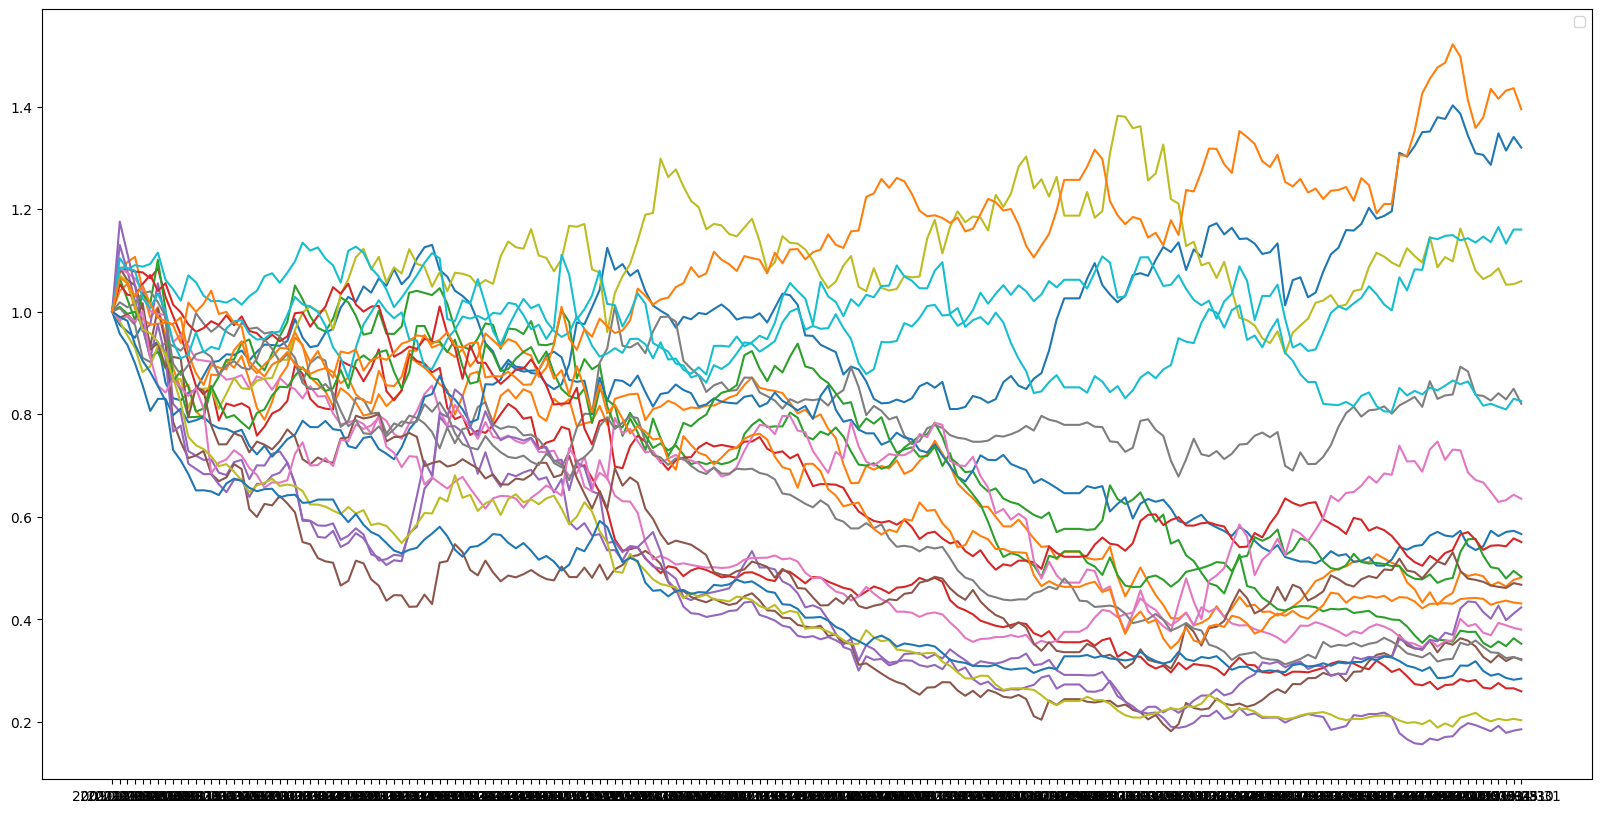

In [ ]:
pivoted_df = result_cummom.pivot(index='Date', columns='variable')
plt.figure(figsize=(20, 10))
plt.plot(pivoted_df)
plt.show()

<Axes: >

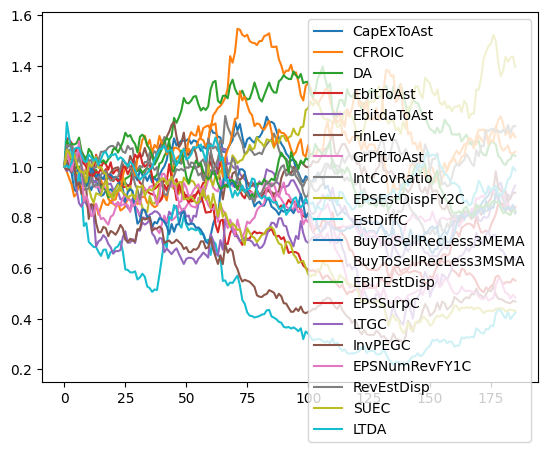

In [149]:
(1 + factor_df.iloc[:, 20:40]).cumprod().plot()

In [150]:
factor_df.describe()

,ROE,ROIC,TobinQ,WCTurn,DebtChg1Y,Rev3MFY1C,Rev3MFY2C,6MAvgChg1MRecC,6MChgTgtPrc,6MChgTgtPrcGap,...,STO_6M,PM6M,CVVolPrc60D,Alpha60M,Alpha12M6MPChg,Alpha18M6MPChg,Alpha36M6MPChg,PM9M,AdjSTO_6M,EPSStab
count,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,...,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000
mean,-0.001102,-0.004109,-0.000218,-0.001020,0.000201,-0.005751,-0.008038,0.001880,-0.003258,-0.005026,...,-0.003713,0.002740,0.001813,0.006768,0.001354,0.002239,0.001708,0.001519,0.004945,-0.004116
std,0.029223,0.023814,0.032658,0.023381,0.025484,0.026517,0.031484,0.027826,0.036549,0.033720,...,0.054817,0.032316,0.025890,0.029382,0.024089,0.024567,0.025507,0.029839,0.032020,0.040299
min,-0.082719,-0.079740,-0.136623,-0.076311,-0.065601,-0.093503,-0.102131,-0.106613,-0.108442,-0.116650,...,-0.213537,-0.105287,-0.073428,-0.066694,-0.058273,-0.060847,-0.053945,-0.088591,-0.115611,-0.149502
25%,-0.022152,-0.018371,-0.018939,-0.013734,-0.015004,-0.023888,-0.028441,-0.013556,-0.028269,-0.025356,...,-0.033260,-0.017424,-0.014846,-0.013603,-0.015044,-0.014988,-0.014368,-0.016802,-0.012054,-0.024971
50%,0.000099,-0.004790,0.000540,-0.002399,0.000164,-0.007191,-0.007631,0.000475,-0.000397,-0.003969,...,-0.002419,0.000593,-0.000626,0.004535,-0.000191,0.000000,0.000000,0.000229,0.005158,-0.004647
75%,0.016814,0.010762,0.018547,0.010318,0.014124,0.012544,0.010411,0.018353,0.019008,0.012824,...,0.023988,0.019058,0.020244,0.024728,0.017140,0.017696,0.012749,0.018374,0.024835,0.016232
max,0.119630,0.061353,0.087781,0.089914,0.107847,0.098381,0.092133,0.095283,0.110057,0.115257,...,0.190349,0.134390,0.064842,0.142890,0.077902,0.082833,0.157566,0.103802,0.083280,0.190963


<Axes: ylabel='Density'>

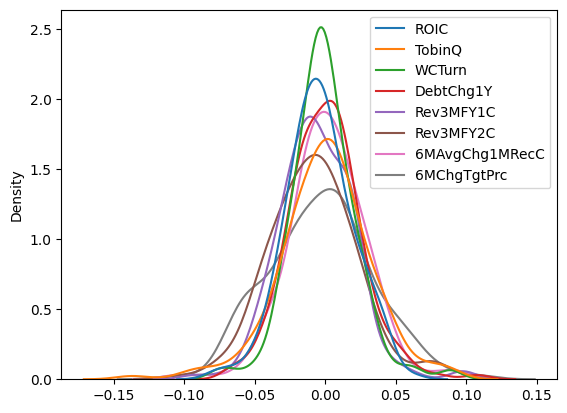

In [153]:
import seaborn as sns

sns.kdeplot(factor_df.iloc[:, 2:10])

In [8]:
factor_df.iloc[1: ,:].cov()

,6MChgTgtPrc,SGAToSalesChg1Y,IO_BreadthStabHD,FinLev,PAdjChg1YFCF,AstAdjChg3YCF,6MAvgChg1MRecC,RDInt,FwdEPC,InvToAst,...,BuyBackChg,AdjEPSNumRevFY2C,Chg3YOPM,ROE,EbitToAst,PAYOUTRATIO,VolAdjRtn12M,SalesToInvCap,MaxRetPayoff,OEP
6MChgTgtPrc,0.001127,0.000164,0.000223,-0.000014,-0.000033,0.000099,0.000006,-0.000612,0.000287,-0.000091,...,-1.068634e-04,0.000162,0.000069,-0.000039,0.000167,0.000093,-0.000166,0.000104,0.000284,0.000112
SGAToSalesChg1Y,0.000164,0.000564,0.000239,0.000137,-0.000042,0.000118,0.000073,-0.000276,0.000161,0.000034,...,-3.011108e-04,0.000184,0.000127,0.000162,0.000144,0.000132,0.000092,0.000115,0.000229,0.000201
IO_BreadthStabHD,0.000223,0.000239,0.000824,0.000174,-0.000132,0.000088,0.000160,-0.000215,0.000208,0.000106,...,9.399984e-07,0.000271,0.000082,0.000119,0.000150,0.000138,0.000214,0.000201,0.000258,0.000271
FinLev,-0.000014,0.000137,0.000174,0.000709,-0.000134,0.000010,0.000069,0.000021,0.000186,-0.000024,...,-5.708541e-05,0.000170,0.000035,0.000109,0.000179,0.000126,0.000212,0.000028,0.000108,0.000165
PAdjChg1YFCF,-0.000033,-0.000042,-0.000132,-0.000134,0.000912,0.000281,-0.000150,0.000072,-0.000179,0.000084,...,-1.524742e-04,0.000112,0.000018,0.000115,0.000080,-0.000103,-0.000140,0.000019,-0.000024,-0.000047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PAYOUTRATIO,0.000093,0.000132,0.000138,0.000126,-0.000103,-0.000081,0.000121,0.000157,0.000083,-0.000016,...,-4.437198e-05,0.000149,0.000027,0.000212,-0.000015,0.000770,0.000087,0.000050,0.000043,0.000058
VolAdjRtn12M,-0.000166,0.000092,0.000214,0.000212,-0.000140,-0.000244,0.000115,0.000144,0.000151,-0.000077,...,5.356449e-05,0.000129,-0.000099,0.000232,-0.000049,0.000087,0.000933,0.000054,0.000005,0.000011
SalesToInvCap,0.000104,0.000115,0.000201,0.000028,0.000019,0.000169,0.000028,-0.000229,0.000158,0.000072,...,-1.981995e-04,0.000140,0.000130,0.000045,0.000140,0.000050,0.000054,0.000463,0.000082,0.000189
MaxRetPayoff,0.000284,0.000229,0.000258,0.000108,-0.000024,0.000033,0.000098,-0.000656,0.000282,-0.000052,...,-1.494208e-04,0.000189,0.000077,-0.000060,0.000184,0.000043,0.000005,0.000082,0.000869,0.000247
